# 03 · Arquitectura downstream

Busca la arquitectura con datos reales, la congela para el resto del proyecto y
comprueba si bate a la persistencia. El control **suspende**, y este cuaderno mide
por qué antes de que se entrene ningún generador.

**Entradas:** `data/processed/ventanas.npz` · `regimenes.parquet` · `canales.parquet`

**Salidas:** la arquitectura congelada con su huella en `models/downstream/`, dos
modelos entrenados, las figuras del apartado, las tablas de `results/metricas/` y un
historial de entrenamiento por cada modelo que se entrena aquí.

**Tiempo:** ~25 min en CPU. El recuento exacto de entrenamientos, figuras e
historiales lo imprime la última celda, que es donde las variables ya existen.

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import downstream, evaluacion, mezclas, regimenes, ventanas

config.cargar_catalogo.cache_clear()

## 1 · La barra no es la del cuaderno 01

La barra del experimento es la persistencia causal **sobre test**, y no la cifra del
cuaderno 01, que se mide sobre la muestra completa y está dominada por train.

| decodificación | qué usa |
|---|---|
| Viterbi | la serie entera, futuro incluido. No es un predictor, es un oráculo |
| filtro causal | hasta `t` y ni un día más. Es la barra |

- `siempre_crisis` está en la tabla para impedir que un recall de crisis alto se lea
  como un logro sin mirar la precisión: tiene el recall máximo posible y es inútil
  (D21, `docs/DECISIONES.md`).
- La barra viene con banda porque las ventanas de crisis del test no son
  observaciones independientes: caen en un puñado de rachas contiguas. Los conteos
  por partición los imprime la celda siguiente.

In [3]:
part = ventanas.cargar_procesado()
train, val, test = part.train, part.val, part.test
n_regimenes, forma_entrada = config.n_regimenes(), part.train.X.shape[1:]
CRISIS = n_regimenes - 1

etiquetador = regimenes.EtiquetadorRegimenes.cargar(src.DIR_PROCESADO / "etiquetador_regimenes.pkl")
canales = pd.read_parquet(src.DIR_PROCESADO / "canales.parquet")
# Una sola decodificacion de cada tipo: `predict_causal` es cara y el resto del
# cuaderno la reutiliza reindexando por fechas.
causal = etiquetador.predict_causal(canales)
viterbi = etiquetador.predict(canales)
hoy_causal = causal.reindex(test.fechas).to_numpy().astype(int)
hoy_viterbi = viterbi.reindex(test.fechas).to_numpy().astype(int)

print(train, val, test, sep="\n")
print("Rachas de crisis ·", " · ".join(
    "{}: {} ventanas en {} rachas".format(n, int((c.y_reg == CRISIS).sum()),
                                          regimenes.tramos_contiguos(c.y_reg, CRISIS))
    for n, c in [("train", train), ("validación", val), ("test", test)]))

Conjunto(n=3696, X=(3696, 60, 20), 2004-04-27 a 2018-12-31)
Conjunto(n=672, X=(672, 60, 20), 2019-05-06 a 2021-12-31)
Conjunto(n=1052, X=(1052, 60, 20), 2022-05-05 a 2026-07-16)
Rachas de crisis · train: 587 ventanas en 8 rachas · validación: 148 ventanas en 2 rachas · test: 110 ventanas en 3 rachas


,f1_macro,balanced_accuracy,accuracy,recall_crisis,precision_crisis,f1_crisis,soporte_crisis,usa_futuro
linea_base,,,,,,,,
mayoritaria_train,0.1654,0.3333,0.3298,0.0000,NaN,0.0000,110,False
azar_estratificado,0.3087,0.3337,0.3641,0.1595,0.1049,0.1265,110,False
siempre_crisis,0.0631,0.3333,0.1046,1.0000,0.1046,0.1893,110,False
persistencia_causal,0.7536,0.7772,0.7719,0.8000,0.6377,0.7097,110,False
persistencia_viterbi,0.7901,0.8044,0.8051,0.8000,0.7154,0.7554,110,True


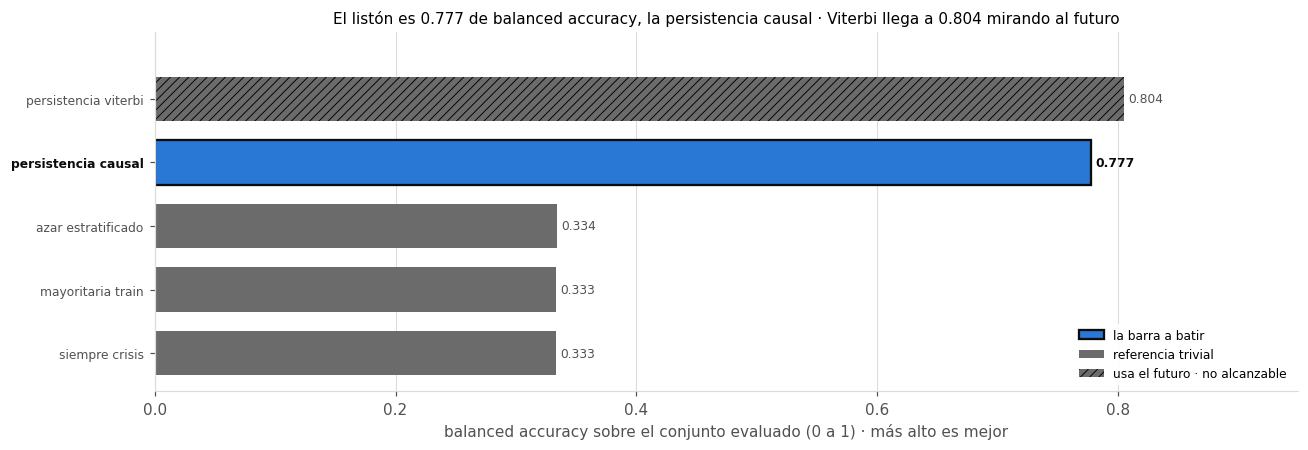

In [4]:
base = evaluacion.lineas_base(test.y_reg.astype(int), hoy_causal, hoy_viterbi,
                              train.y_reg.astype(int), n_regimenes)
barra = base.loc["persistencia_causal", downstream.METRICA_SELECCION]

fig, eje = plt.subplots(figsize=(12, 4.2))
viz.lineas_base(base, downstream.METRICA_SELECCION, eje=eje)
viz.guardar(fig, "barra_a_batir")

base.round(4)

In [5]:
METRICAS = (downstream.METRICA_SELECCION, downstream.METRICA_DESEMPATE)
ROTULO = {downstream.METRICA_SELECCION: "balanced accuracy",
          downstream.METRICA_DESEMPATE: "recall de crisis"}
TONO_MET = {downstream.METRICA_SELECCION: viz.PALETA[0],
            downstream.METRICA_DESEMPATE: viz.PALETA[7]}

# El bootstrap es de BLOQUES de 81 ventanas (`pasado + horizonte`): remuestrear
# ventana a ventana supondria independencia y estrecharia la banda por un factor 3.
banda = {("persistencia", m): evaluacion.banda_bloques(test.y_reg.astype(int), hoy_causal, m)
         for m in METRICAS}

for m in METRICAS:
    lo, hi = banda["persistencia", m]
    print("Barra a batir · {} {:.3f} con banda de bloques [{:.3f}, {:.3f}] · ancho {:.3f}".format(
        ROTULO[m], base.loc["persistencia_causal", m], lo, hi, hi - lo))

Barra a batir · balanced accuracy 0.777 con banda de bloques [0.681, 0.860] · ancho 0.178
Barra a batir · recall de crisis 0.800 con banda de bloques [0.560, 1.000] · ancho 0.440


## 2 · Seis candidatas, cada una moviendo un solo eje

El enunciado pide *buscar* una arquitectura con datos reales, y la búsqueda está
diseñada para que el resultado se pueda defender: cada candidata mueve **un solo
eje** respecto a `cnn_base`.

- `lineal` quita la convolución entera y es el control de si aporta algo;
  `cnn_pequena` y `cnn_ancha` mueven la capacidad; `cnn_kernel7` el campo receptivo;
  `cnn_pool_global` la agregación temporal.
- Tres semillas por candidata: con una sola corrida la dispersión no se puede medir,
  y sin dispersión no se puede afirmar que una gane.
- **Se puntúa sobre validación, nunca sobre test**, y con `balanced_accuracy`, no
  con f1-macro: validación tiene más del doble de prevalencia de crisis que test
  porque su tramo contiene el COVID, y la balanced accuracy es exactamente
  invariante ante ese salto mientras que el f1-macro no lo es. La medición de
  cuánto se mueve el f1-macro está en D17 (`docs/DECISIONES.md`) y aquí no se
  recalcula.

### La parada temprana monitoriza la métrica que decide, no `val_loss`

Los dos mínimos no coinciden. La entropía cruzada de validación está dominada por el
desajuste de prevalencias entre train y validación, no por lo que el modelo aprende,
así que parar por ella descarta épocas que sí mejoran la métrica que se reporta
(D20, `docs/DECISIONES.md`).

Es una decisión medida, no una preferencia: el apartado 6 recorre todos los
entrenamientos de este cuaderno y cuenta lo que habría costado.

In [6]:
SEMILLAS = (0, 1, 2)
tabla = downstream.buscar(downstream.CANDIDATAS, train, val, "regimen",
                          n_clases=n_regimenes, semillas=SEMILLAS)
resumen = downstream.resumen_busqueda(tabla)
clave, arquitectura = downstream.elegir(tabla)

MEDIA = downstream.METRICA_SELECCION + "_media"
DESV = downstream.METRICA_SELECCION + "_desv"
orden = resumen.sort_values(MEDIA, ascending=False)
margen = orden[MEDIA].iloc[0] - orden[MEDIA].iloc[1]
empatan = int((orden[MEDIA] >= orden[MEDIA].iloc[0] - orden[DESV].iloc[0]).sum())
cara = orden["segundos_por_epoca_media"].idxmax()

print("Gana", clave, "por", round(margen, 4), "sobre la segunda · dispersión entre semillas",
      round(orden[DESV].iloc[0], 4), "·", empatan, "candidatas dentro de una desviación")
print("Tiempo por época: {} {:.3f} s frente a {} {:.3f} s · factor {:.0f}".format(
    clave, orden.loc[clave, "segundos_por_epoca_media"], cara,
    orden.loc[cara, "segundos_por_epoca_media"],
    orden.loc[cara, "segundos_por_epoca_media"] / orden.loc[clave, "segundos_por_epoca_media"]))

Gana lineal por 0.0039 sobre la segunda · dispersión entre semillas 0.0081 · 2 candidatas dentro de una desviación
Tiempo por época: lineal 0.397 s frente a cnn_ancha 7.447 s · factor 19


,balanced_accuracy_media,balanced_accuracy_desv,f1_macro_media,recall_crisis_media,parametros_media,segundos_por_epoca_media
candidata,,,,,,
lineal,0.6956,0.0081,0.6504,0.5338,3603.0,0.3967
cnn_kernel7,0.6917,0.0122,0.6597,0.4842,271315.0,3.6467
cnn_base,0.6849,0.0391,0.6620,0.5180,167891.0,3.1533
cnn_ancha,0.6845,0.0092,0.6454,0.5405,533123.0,7.4467
cnn_pequena,0.6681,0.0168,0.6522,0.4257,69859.0,1.2367
cnn_pool_global,0.6617,0.0203,0.6542,0.4234,91091.0,2.6767


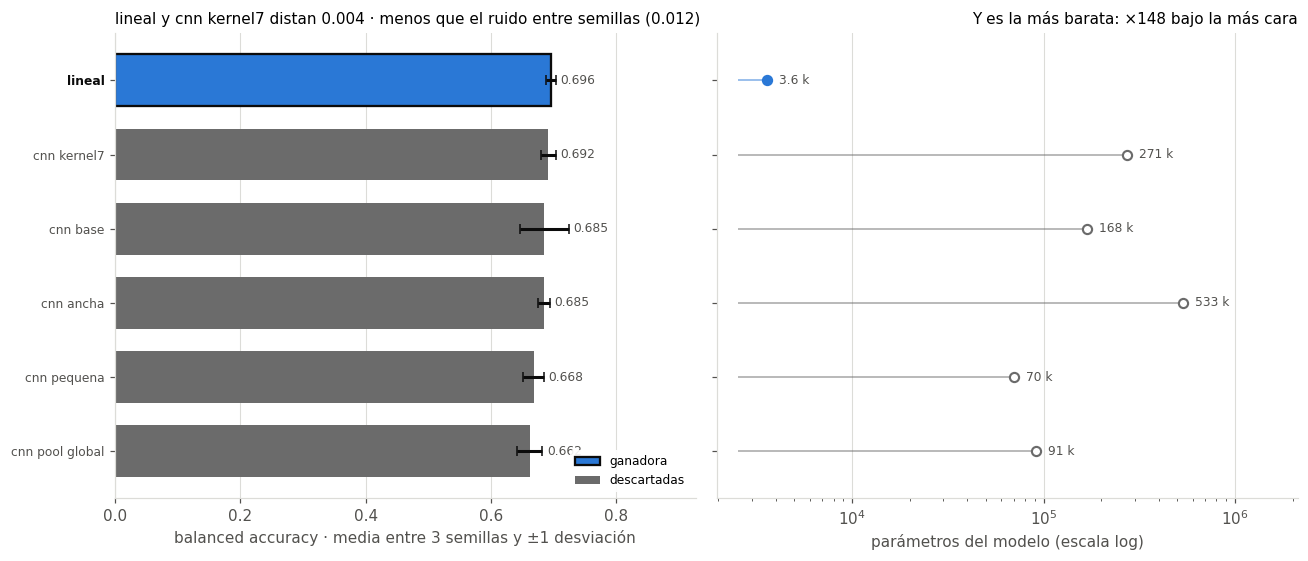

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
viz.busqueda_arquitectura(resumen, MEDIA, DESV, ganadora=clave, eje=ejes)
viz.guardar(fig, "busqueda_arquitectura")

orden[[MEDIA, DESV, "f1_macro_media", "recall_crisis_media",
       "parametros_media", "segundos_por_epoca_media"]].round(4)

### Capacidad sin retorno

El panel de la derecha de la figura anterior es de **parámetros**, no de coste de
reloj. Y las curvas de las 18 corridas de la búsqueda dicen a qué se dedica esa
capacidad: las convolucionales hunden la pérdida de entrenamiento en muy pocas
épocas y la balanced accuracy de validación no se mueve con ellas. El eje horizontal
va recortado a las épocas de cada candidata, porque paran en momentos muy distintos.

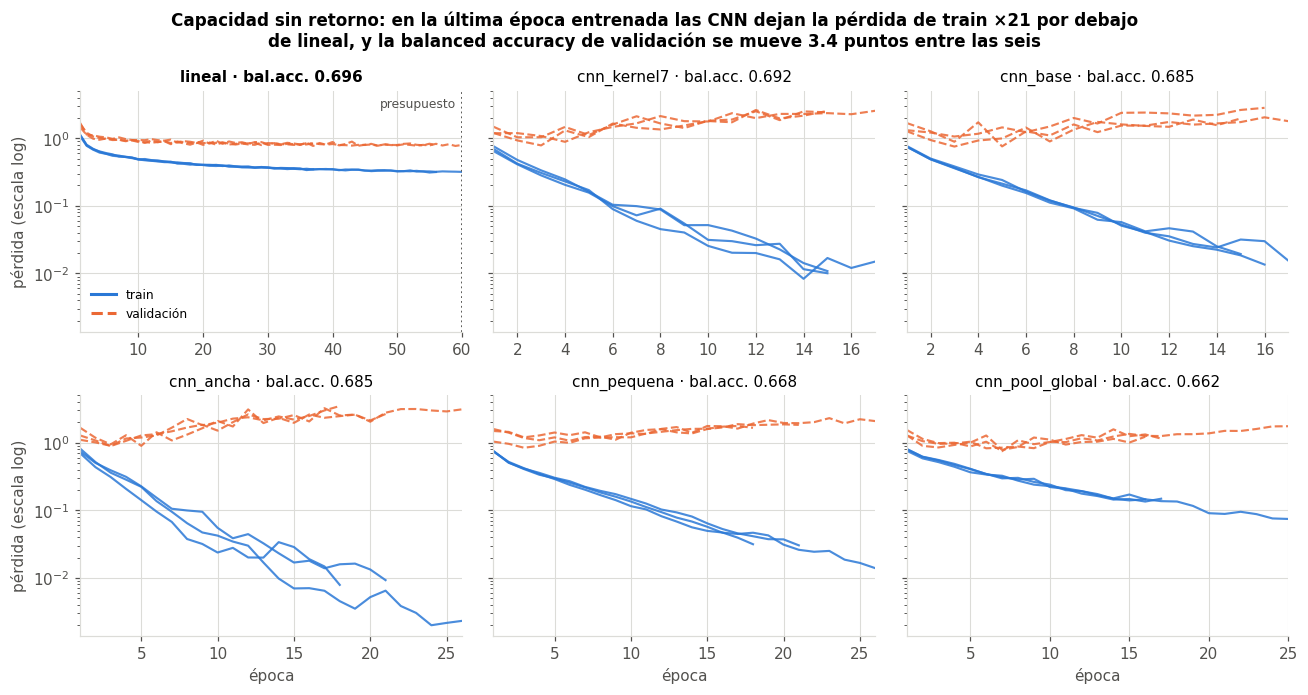

In [8]:
fig, ejes = plt.subplots(2, 3, figsize=(12, 6.4), sharey=True)
_fin_train = {}
for _eje, _n in zip(ejes.ravel(), orden.index):
    _cs = [pd.read_csv(src.DIR_HISTORIALES / f"busqueda__{_n}__s{_s}__regimen.csv")
           for _s in SEMILLAS]
    for _c in _cs:
        _eje.plot(_c["epoca"], _c["loss"], color=viz.PALETA[0], lw=1.4, alpha=0.85)
        _eje.plot(_c["epoca"], _c["val_loss"], color=viz.PALETA[1], lw=1.4, ls="--", alpha=0.85)
    _ultima = max(len(_c) for _c in _cs)
    _fin_train[_n] = float(np.median([_c["loss"].iloc[-1] for _c in _cs]))
    if _ultima >= downstream.PRESUPUESTO.epocas:
        _eje.axvline(downstream.PRESUPUESTO.epocas, color=viz.TINTA_SECUNDARIA, ls=":", lw=1.2)
        _eje.annotate("presupuesto", (downstream.PRESUPUESTO.epocas, 0.97),
                      xycoords=("data", "axes fraction"), xytext=(-4, 0),
                      textcoords="offset points", ha="right", va="top", fontsize=8,
                      color=viz.TINTA_SECUNDARIA)
    _eje.set_xlim(1, _ultima)
    _eje.set_yscale("log")
    _eje.set_title(f"{_n} · bal.acc. {orden.loc[_n, MEDIA]:.3f}", fontsize=10,
                   fontweight="bold" if _n == clave else "normal")

for _eje in ejes[1]:
    _eje.set_xlabel("época")
for _eje in ejes[:, 0]:
    _eje.set_ylabel("pérdida (escala log)")
ejes[0, 0].plot([], [], color=viz.PALETA[0], label="train")
ejes[0, 0].plot([], [], color=viz.PALETA[1], ls="--", label="validación")
ejes[0, 0].legend(loc="lower left", fontsize=8)

_razon = _fin_train[clave] / np.median([v for k, v in _fin_train.items() if k != clave])
_rango = orden[MEDIA].max() - orden[MEDIA].min()
fig.suptitle(f"Capacidad sin retorno: en la última época entrenada las CNN dejan la pérdida "
             f"de train ×{_razon:.0f} por debajo\nde {clave}, y la balanced accuracy de "
             f"validación se mueve {100 * _rango:.1f} puntos entre las seis",
             fontsize=11, fontweight="bold")
viz.guardar(fig, "03_convergencia_busqueda")

## 3 · Gana la que no tiene convolución

La que encabeza es `lineal`, una multinomial sobre la ventana aplanada, y
`cnn_kernel7` cae dentro de su desviación entre semillas: no están separadas por
nada. Las cifras de parámetros, tiempo por época y margen las imprime la celda de la
búsqueda; aquí no se transcriben.

- El empate es el resultado, no un accidente: con los pocos bloques independientes
  que tiene train —el apartado 5 los cuenta— la convolución no tiene de dónde sacar
  ventaja.
- Se congela `lineal` porque encabeza la métrica, gana el desempate por recall de
  crisis y es la más barata, y porque D19 (todo dimensionado para CPU) obliga a que
  el cuaderno 12 quepa sin GPU.
- A partir de aquí la arquitectura y su presupuesto viven en
  `models/downstream/arquitectura.json` con su huella: el cuaderno 12 los lee de ahí
  con `downstream.cargar_congelada()` en vez de heredar el valor por defecto del
  código, de modo que un cambio entre cuadernos se detecta en vez de contaminar
  cientos de entrenamientos.

In [9]:
config.fijar_semillas()
modelo = downstream.construir("regimen", forma_entrada, n_clases=n_regimenes,
                              arquitectura=arquitectura)
historial = downstream.entrenar(modelo, train.X, train.y_reg, val.X, val.y_reg, tarea="regimen")
downstream.guardar_historial(historial, "baseline_regimen")
ruta_arq = downstream.congelar(arquitectura)

# La huella cubre arquitectura Y presupuesto: es la que valida `cargar_congelada`.
# El assert reconcilia lo ESCRITO en disco con lo recalculado aqui; sin el, el
# cuaderno 12 podria cargar una congelacion que no es la que este cuaderno midio.
_arq_leida, _pres_leido = downstream.cargar_congelada(ruta_arq)
huella = downstream.huella(arquitectura, downstream.PRESUPUESTO)
assert huella == downstream.huella(_arq_leida, _pres_leido), "la huella escrita no coincide"

print(arquitectura, "· huella", huella)
print(downstream.PRESUPUESTO)

CNN1D(filtros sin conv · kernel 3 · aplanado · sin densa · dropout 0.3) · huella df79bcab4ed6
Presupuesto(60 épocas · lote 256 · paciencia 12 · para por balanced_accuracy, val_mae en volatilidad)


val_loss entra en meseta desde la época 30: desviación 0.0289, y 6 épocas caen dentro de una desviación de su mínimo (época 38). Su argmin no es una época distinguible.


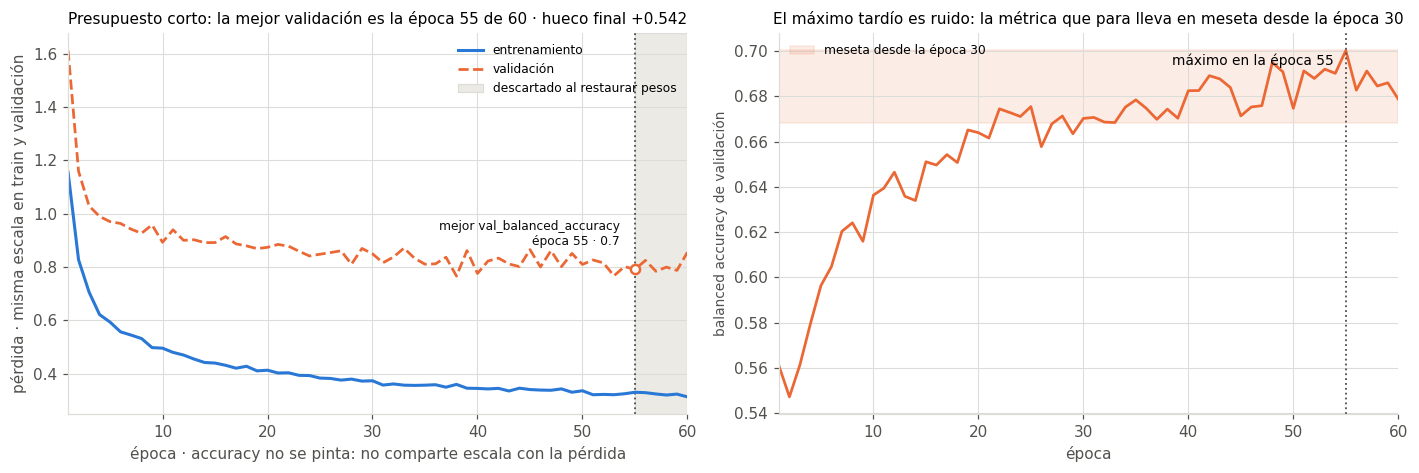

In [10]:
curva = pd.read_csv(src.DIR_HISTORIALES / "baseline_regimen.csv")
MESETA = 30

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4))
viz.convergencia_downstream(curva, eje=ejes[0])

_cola = curva[curva["epoca"] >= MESETA]
_eje = ejes[1]
_eje.axhspan(_cola["val_balanced_accuracy"].min(), _cola["val_balanced_accuracy"].max(),
             color=viz.PALETA[1], alpha=0.12, zorder=0, label=f"meseta desde la época {MESETA}")
_eje.plot(curva["epoca"], curva["val_balanced_accuracy"], color=viz.PALETA[1], lw=1.8)
_pico = int(curva["epoca"].iloc[curva["val_balanced_accuracy"].idxmax()])
_eje.axvline(_pico, color=viz.TINTA_SECUNDARIA, ls=":", lw=1.2)
_eje.annotate(f"máximo en la época {_pico}", (_pico, curva["val_balanced_accuracy"].max()),
              xytext=(-8, -2), textcoords="offset points", ha="right", va="top", fontsize=9)
_eje.set_xlim(float(curva["epoca"].iloc[0]), float(curva["epoca"].iloc[-1]))
_eje.set_xlabel("época")
_eje.set_ylabel("balanced accuracy de validación", fontsize=9)
_eje.legend(loc="upper left", fontsize=8)
_eje.set_title(f"El máximo tardío es ruido: la métrica que para lleva en meseta "
               f"desde la época {MESETA}", fontsize=10, fontweight="normal")
viz.guardar(fig, "aprendizaje_baseline_regimen")

_ruido = float(_cola["val_loss"].std())
_min = float(curva["val_loss"].min())
print("val_loss entra en meseta desde la época {}: desviación {:.4f}, y {} épocas caen dentro "
      "de una desviación de su mínimo (época {}). Su argmin no es una época distinguible."
      .format(MESETA, _ruido, int((curva["val_loss"] <= _min + _ruido).sum()),
              int(curva["epoca"].iloc[curva["val_loss"].idxmin()])))

In [11]:
metricas = evaluacion.evaluar(modelo, test.X, test.y_reg, "regimen")

print("Parámetros:", modelo.count_params(), "· épocas efectivas:", len(curva))
evaluacion.como_serie(metricas)

Parámetros: 3603 · épocas efectivas: 60


f1_macro             0.4992
balanced_accuracy    0.5754
accuracy             0.5219
recall_crisis        0.5909
precision_crisis     0.1852
f1_crisis             0.282
soporte_crisis          110
conjunto               test
dtype: object

## 4 · El control bloqueante suspende

La regla se fijó antes de mirar: la arquitectura congelada tiene que batir a la
persistencia causal en balanced accuracy **y** en recall de crisis sobre test. No lo
hace en ninguna de las dos.

El veredicto entero cabe en una figura: las dos métricas del control, la barra y el
modelo, cada uno con su banda de bloques. **Esta es la figura que va al slide.**

- El suspenso se sostiene solo, porque el control se definió sobre el punto. Lo que
  añaden las bandas es el aviso que el cuaderno 12 necesita: **las bandas de bloques
  del modelo y de la barra se solapan**, así que este test no resuelve diferencias
  pequeñas. La cifra del solapamiento va en el título de la figura.
- La matriz de confusión dice dónde se rompe, y el presupuesto de alarmas dice
  cuánto cuesta: el modelo enciende la alarma de crisis muchas más veces de las que
  hay crisis, y casi todas las falsas vienen de la fila de transición.
- Esto no invalida el taller: **lo afila**. El experimento pregunta si los datos
  sintéticos ayudan cuando los reales escasean, y el apartado 5 mide que aquí
  escasean de verdad.

In [12]:
predicho = modelo.predict(test.X, verbose=0, batch_size=512).argmax(axis=1)
matriz = evaluacion.matriz_confusion(test.y_reg.astype(int), predicho, n_regimenes)

comparacion = pd.DataFrame({
    "modelo congelado": {k: v for k, v in metricas.items() if isinstance(v, float)},
    "persistencia causal": base.loc["persistencia_causal"].to_dict(),
}).T[["balanced_accuracy", "f1_macro", "accuracy", "recall_crisis", "precision_crisis"]]

veredicto = all(metricas[m] >= base.loc["persistencia_causal", m] for m in METRICAS)
print("Control bloqueante:", "SUPERADO" if veredicto else "SUSPENDIDO", "·",
      " · ".join("{} {:.4f} frente a {:.4f}".format(
          ROTULO[m], metricas[m], base.loc["persistencia_causal", m]) for m in METRICAS))
print("Crisis predichas:", int((predicho == CRISIS).sum()),
      "· crisis reales:", int((test.y_reg == CRISIS).sum()))

comparacion.round(4)

Control bloqueante: SUSPENDIDO · balanced accuracy 0.5754 frente a 0.7772 · recall de crisis 0.5909 frente a 0.8000
Crisis predichas: 351 · crisis reales: 110


,balanced_accuracy,f1_macro,accuracy,recall_crisis,precision_crisis
modelo congelado,0.575423,0.499237,0.521863,0.590909,0.185185
persistencia causal,0.777171,0.753572,0.771863,0.8,0.637681


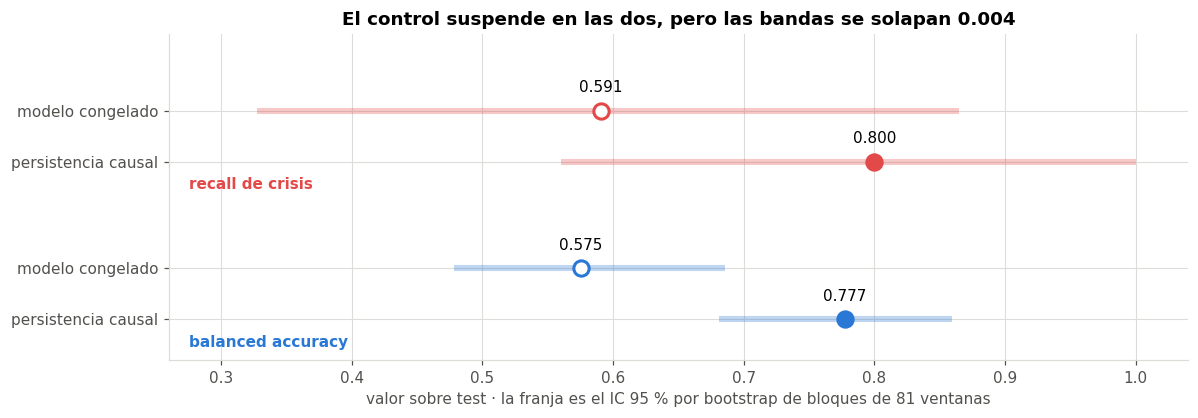

In [13]:
for _m in METRICAS:
    banda["modelo", _m] = evaluacion.banda_bloques(test.y_reg.astype(int), predicho, _m)

fig, eje = plt.subplots(figsize=(11, 3.9))
_y = 0.0
for _m in METRICAS:
    _t = TONO_MET[_m]
    for _q, _v in (("persistencia", base.loc["persistencia_causal", _m]),
                   ("modelo", metricas[_m])):
        _lo, _hi = banda[_q, _m]
        eje.plot([_lo, _hi], [_y, _y], color=_t, lw=4, alpha=0.30, solid_capstyle="butt")
        eje.plot(_v, _y, "o", ms=10, color=_t, mew=2, zorder=3,
                 markerfacecolor=_t if _q == "persistencia" else "white")
        eje.annotate(f"{_v:.3f}", (_v, _y), xytext=(0, 12), textcoords="offset points",
                     ha="center", fontsize=10)
        _y += 1
    eje.text(0.02, _y - 2.45, ROTULO[_m], transform=eje.get_yaxis_transform(),
             fontsize=10, fontweight="bold", color=_t, va="center")
    _y += 1.1

# El signo importa: si en otra ejecucion las bandas dejaran de tocarse, el titulo
# no puede seguir diciendo que se solapan.
_solape = banda["modelo", METRICAS[0]][1] - banda["persistencia", METRICAS[0]][0]
_frase = (f"pero las bandas se solapan {_solape:.3f}" if _solape > 0
          else f"y las bandas ya ni se tocan ({-_solape:.3f})")
eje.set_yticks([0, 1, 3.1, 4.1])
eje.set_yticklabels(["persistencia causal", "modelo congelado"] * 2)
eje.set_xlim(min(0.26, min(v for par in banda.values() for v in par) - 0.03), 1.04)
eje.set_ylim(-0.8, _y - 0.6)
eje.set_xlabel("valor sobre test · la franja es el IC 95 % por bootstrap de bloques de 81 ventanas")
eje.set_title(f"El control suspende en las dos, {_frase}")
viz.guardar(fig, "03_veredicto")

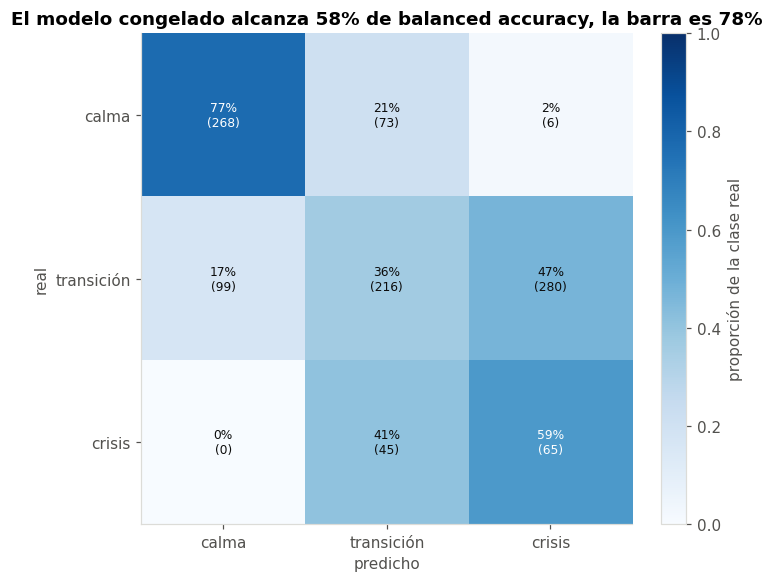

In [14]:
fig, eje = plt.subplots(figsize=(6.6, 5.4))
viz.confusion(matriz, "El modelo congelado alcanza {:.0%} de balanced accuracy, la barra es {:.0%}".format(
    metricas["balanced_accuracy"], base.loc["persistencia_causal", "balanced_accuracy"]), eje=eje)
viz.guardar(fig, "confusion_baseline")

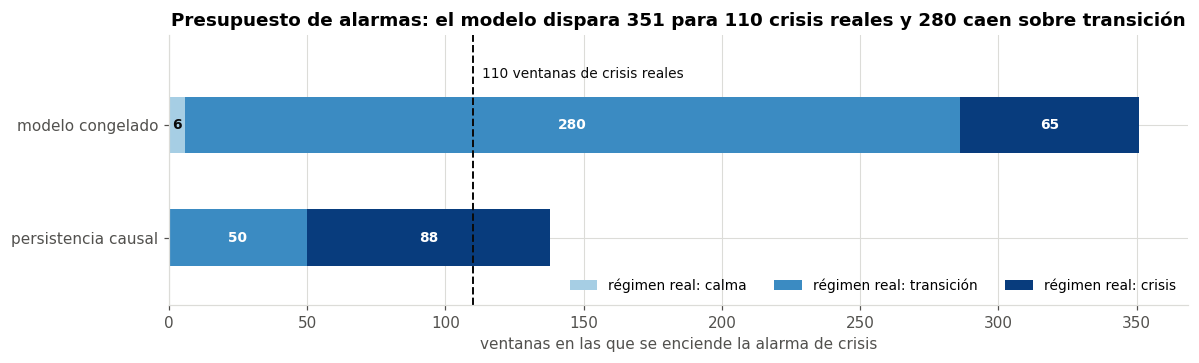

In [15]:
TONOS_REG = viz.rampa_secuencial(n_regimenes)
NOMBRES_REG = evaluacion.nombres_regimenes(n_regimenes)
FUENTES = {"modelo congelado": predicho, "persistencia causal": hoy_causal}

fig, eje = plt.subplots(figsize=(11, 3.4))
_pos = np.arange(len(FUENTES))[::-1]
_izq = np.zeros(len(FUENTES))
_reparto = np.array([np.bincount(test.y_reg.astype(int)[p == CRISIS], minlength=n_regimenes)
                     for p in FUENTES.values()], dtype=float)
for _k in range(n_regimenes):
    eje.barh(_pos, _reparto[:, _k], left=_izq, height=0.5, color=TONOS_REG[_k],
             label=f"régimen real: {NOMBRES_REG[_k]}")
    for _yy, _x0, _w in zip(_pos, _izq, _reparto[:, _k]):
        if _w:
            eje.annotate(f"{int(_w)}", (_x0 + _w / 2, _yy), ha="center", va="center", fontsize=9,
                         fontweight="bold", color="white" if _k else viz.TINTA_PRIMARIA)
    _izq += _reparto[:, _k]

_reales = int((test.y_reg == CRISIS).sum())
eje.axvline(_reales, color=viz.TINTA_PRIMARIA, ls="--", lw=1.3)
eje.annotate(f"{_reales} ventanas de crisis reales", (_reales, 1.42), xytext=(6, 0),
             textcoords="offset points", fontsize=9, color=viz.TINTA_PRIMARIA)
eje.set_yticks(_pos)
eje.set_yticklabels(FUENTES.keys())
eje.set_ylim(-0.6, 1.8)
eje.set_xlabel("ventanas en las que se enciende la alarma de crisis")
eje.legend(loc="lower right", fontsize=9, ncols=n_regimenes)
eje.set_title(f"Presupuesto de alarmas: el modelo dispara {int(_izq[0])} para {_reales} crisis "
              f"reales y {int(_reparto[0, 1])} caen sobre transición")
viz.guardar(fig, "03_alarmas_crisis")

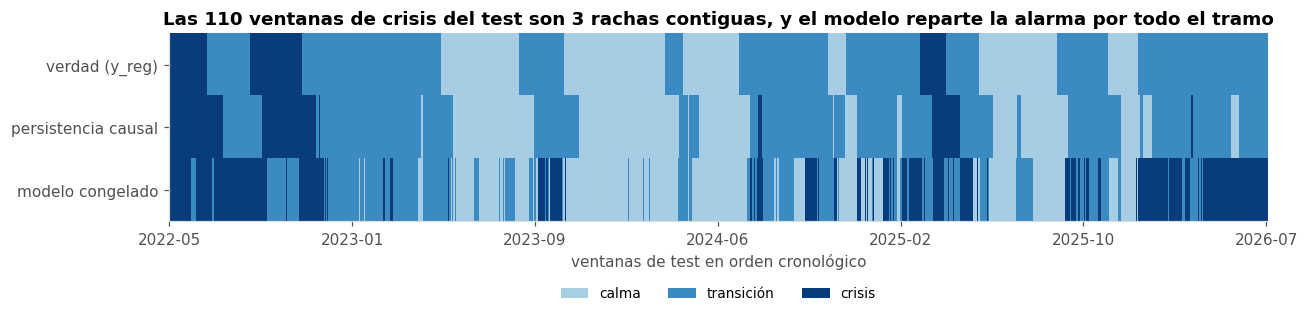

In [16]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

CARRILES = {"verdad (y_reg)": test.y_reg.astype(int), "persistencia causal": hoy_causal,
            "modelo congelado": predicho}
_fechas = pd.DatetimeIndex(test.fechas)

fig, eje = plt.subplots(figsize=(12, 3.2))
eje.imshow(np.vstack(list(CARRILES.values())), aspect="auto", interpolation="nearest",
           cmap=ListedColormap(TONOS_REG), vmin=-0.5, vmax=n_regimenes - 0.5,
           extent=(0, len(_fechas), len(CARRILES) - 0.5, -0.5))
eje.set_yticks(range(len(CARRILES)))
eje.set_yticklabels(CARRILES.keys())
_paso = max(len(_fechas) // 6, 1)
eje.set_xticks(np.arange(0, len(_fechas), _paso) + 0.5)
eje.set_xticklabels([f.strftime("%Y-%m") for f in _fechas[::_paso]])
eje.grid(False)
eje.set_xlabel("ventanas de test en orden cronológico")
eje.legend(handles=[Patch(facecolor=TONOS_REG[k], label=NOMBRES_REG[k])
                    for k in range(n_regimenes)],
           loc="upper center", bbox_to_anchor=(0.5, -0.28), ncols=n_regimenes, fontsize=9)
eje.set_title("Las {} ventanas de crisis del test son {} rachas contiguas, y el modelo reparte "
              "la alarma por todo el tramo".format(
                  int((test.y_reg == CRISIS).sum()),
                  regimenes.tramos_contiguos(test.y_reg, CRISIS)))
viz.guardar(fig, "03_regimenes_test")

## 5 · El tamaño muestral honesto no son las ventanas

Cada ventana comparte 59 de sus 60 días con la vecina, así que las ventanas de train
no son observaciones independientes: caben en un puñado de **bloques disjuntos** de
81 sesiones, que es `pasado + horizonte` y la distancia a la que dos ventanas dejan
de compartir ni un solo día.

- Ese, y no el número de ventanas, es el tamaño muestral con el que hay que leer
  cualquier comparación. Los conteos por partición los imprime la celda siguiente.
- Se cuenta con `len(parte) // 81`, que es la convención publicada del proyecto. La
  división entera descarta el bloque incompleto del final: es deliberado, un bloque
  a medias no es un bloque independiente.
- Las rachas de crisis por partición del apartado 1 son otra cosa distinta de los
  episodios de estrés del cuaderno 00, que son rachas de `vix_nivel_z > 2` fusionadas
  sobre la muestra completa. No se reconcilian: cuentan objetos distintos.

In [17]:
LARGO_BLOQUE = config.ventanas().pasado + config.ventanas().horizonte
bloques = {n: len(c) // LARGO_BLOQUE
           for n, c in [("train", train), ("validación", val), ("test", test)]}

print("Bloques disjuntos de", LARGO_BLOQUE, "sesiones ·",
      " · ".join(f"{n}: {b} bloques de {len(c)} ventanas"
                 for (n, b), c in zip(bloques.items(), (train, val, test))))

Bloques disjuntos de 81 sesiones · train: 45 bloques de 3696 ventanas · validación: 8 bloques de 672 ventanas · test: 12 bloques de 1052 ventanas


### La información sí está en la ventana; la tarea directa la desperdicia

La misma entrada y la misma arquitectura, entrenadas a reproducir el régimen de
**hoy**, aciertan mucho más; y encadenar esa predicción con la persistencia recupera
buena parte del hueco hasta la barra, aunque no la alcanza.

- El panel de arriba de la figura mide **acuerdo con el filtro causal**, no verdad de
  campo: `y_reg` sale de un decodificador, así que la tarea auxiliar dice si la
  ventana reproduce la salida del etiquetador, no si acierta un hecho observable.
- Aquí la convolución **sí** paga: `cnn_ancha` supera a `lineal` en la tarea auxiliar,
  justo lo contrario que en la directa. Que el orden entre arquitecturas se invierta
  al cambiar el objetivo es la señal de que el problema está en cómo se plantea la
  tarea, no en los datos.
- Adoptar el encadenado toca D8 (los generadores modelan el bloque conjunto y
  tendrían que producir también el régimen de hoy), así que es una decisión del grupo
  y no se aplica aquí.

In [18]:
SEP = " · "
hoy = {n: causal.reindex(c.fechas).to_numpy().astype(int)
       for n, c in [("train", train), ("val", val), ("test", test)]}
filas = {}

for nombre in (clave, "cnn_ancha"):
    config.fijar_semillas()
    auxiliar = downstream.construir("regimen", forma_entrada, n_clases=n_regimenes,
                                    arquitectura=downstream.CANDIDATAS[nombre])
    h = downstream.entrenar(auxiliar, train.X, hoy["train"], val.X, hoy["val"], tarea="regimen")
    downstream.guardar_historial(h, "auxiliar_regimen_hoy__" + nombre)
    p = auxiliar.predict(test.X, verbose=0, batch_size=512).argmax(axis=1)
    filas["hoy" + SEP + nombre] = evaluacion.metricas_regimen(hoy["test"], p, n_regimenes)
    filas["encadenado" + SEP + nombre] = evaluacion.linea_base_persistencia(
        test.y_reg.astype(int), p, n_regimenes)

In [19]:
DIRECTO = "directo" + SEP + clave
filas[DIRECTO] = {k: v for k, v in metricas.items() if isinstance(v, float)}
filas["persistencia causal"] = base.loc["persistencia_causal"].to_dict()
informacion = pd.DataFrame(filas).T

mejor_enc = informacion.filter(like="encadenado", axis=0)[downstream.METRICA_SELECCION].max()
recuperado = (mejor_enc - informacion.loc[DIRECTO, downstream.METRICA_SELECCION]) / (
    barra - informacion.loc[DIRECTO, downstream.METRICA_SELECCION])

print("Las filas 'hoy' miden contra el régimen de HOY decodificado con el filtro causal,",
      "no contra y_reg: dicen si la ventana contiene el estado, no si predice el futuro.")
print("El encadenado recupera el {:.0%} del hueco de balanced accuracy que separa a la tarea "
      "directa de la barra.".format(recuperado))

informacion[["balanced_accuracy", "f1_macro", "accuracy", "recall_crisis"]].round(4)

Las filas 'hoy' miden contra el régimen de HOY decodificado con el filtro causal, no contra y_reg: dicen si la ventana contiene el estado, no si predice el futuro.
El encadenado recupera el 71% del hueco de balanced accuracy que separa a la tarea directa de la barra.


,balanced_accuracy,f1_macro,accuracy,recall_crisis
hoy · lineal,0.681519,0.585774,0.607414,0.702899
encadenado · lineal,0.673793,0.548837,0.564639,0.790909
hoy · cnn_ancha,0.808454,0.8222,0.851711,0.630435
encadenado · cnn_ancha,0.719061,0.718123,0.749049,0.609091
directo · lineal,0.575423,0.499237,0.521863,0.590909
persistencia causal,0.777171,0.753572,0.771863,0.8


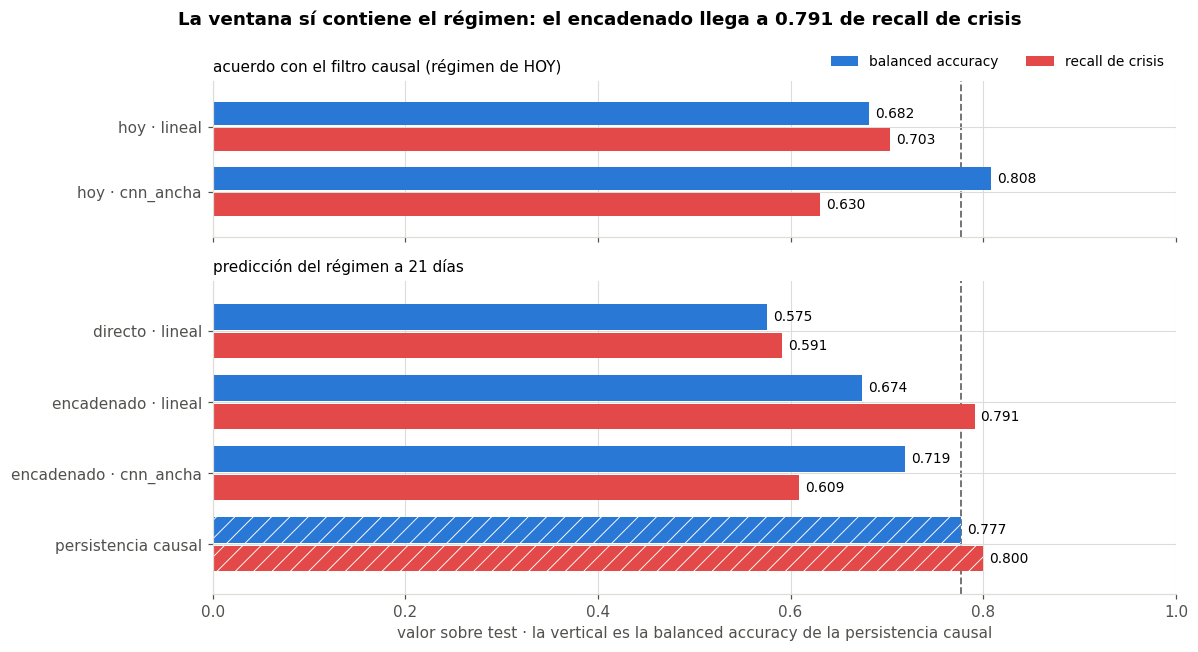

In [20]:
_hoy_f = list(informacion.filter(like="hoy", axis=0).index)
_a21_f = [DIRECTO] + list(informacion.filter(like="encadenado", axis=0).index) + \
         ["persistencia causal"]

fig, ejes = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True,
                         gridspec_kw={"height_ratios": [len(_hoy_f), len(_a21_f)]})
for _eje, _filas, _rot in [(ejes[0], _hoy_f, "acuerdo con el filtro causal (régimen de HOY)"),
                           (ejes[1], _a21_f, "predicción del régimen a 21 días")]:
    _pos = np.arange(len(_filas))[::-1]
    for _j, _m in enumerate(METRICAS):
        _v = informacion.loc[_filas, _m].to_numpy(dtype=float)
        _d = 0.2 if _j == 0 else -0.2
        _eje.barh(_pos + _d, _v, height=0.36, color=TONO_MET[_m], label=ROTULO[_m],
                  hatch=["//" if f == "persistencia causal" else "" for f in _filas],
                  edgecolor="white", linewidth=0)
        for _p, _x in zip(_pos, _v):
            _eje.annotate(f"{_x:.3f}", (_x, _p + _d), xytext=(4, 0), textcoords="offset points",
                          va="center", fontsize=9)
    _eje.axvline(barra, color=viz.GRIS_CONTEXTO, ls="--", lw=1.2, zorder=0)
    _eje.set_yticks(_pos)
    _eje.set_yticklabels(_filas)
    _eje.set_ylim(-0.7, len(_filas) - 0.3)
    _eje.set_title(_rot, fontsize=10, fontweight="normal", loc="left")

ejes[0].legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), fontsize=9, ncols=2)
ejes[1].set_xlim(0, 1.0)
ejes[1].set_xlabel("valor sobre test · la vertical es la balanced accuracy de la persistencia causal")
fig.suptitle("La ventana sí contiene el régimen: el encadenado llega a {:.3f} de recall de crisis"
             .format(informacion.filter(like="encadenado", axis=0)["recall_crisis"].max()),
             fontsize=12, fontweight="bold")
viz.guardar(fig, "03_informacion_disponible")

## 6 · Reponderar la pérdida

Reponderar es la alternativa gratuita al desbalance (D15: el barrido incluye
obligatoriamente una versión con `class_weight` inverso a la frecuencia). Sube el
recall de crisis y hunde todo lo demás, y por eso es la vara contra la que se leerá
cualquier mejora que traigan los sintéticos: lo que consiga `class_weight` no lo
consiguen ellos.

La tabla de tres columnas de la celda siguiente es el argumento entero y se lee de un
vistazo; no hace falta figura.

In [21]:
config.fijar_semillas()
con_pesos = downstream.construir("regimen", forma_entrada, n_clases=n_regimenes,
                                 arquitectura=arquitectura)
h_pesos = downstream.entrenar(con_pesos, train.X, train.y_reg, val.X, val.y_reg,
                              tarea="regimen", usar_pesos=True)
downstream.guardar_historial(h_pesos, "baseline_regimen_pesos")
metricas_pesos = evaluacion.evaluar(con_pesos, test.X, test.y_reg, "regimen")

pd.DataFrame({"sin pesos": {k: v for k, v in metricas.items() if isinstance(v, float)},
              "con pesos": {k: v for k, v in metricas_pesos.items() if isinstance(v, float)},
              "persistencia causal": base.loc["persistencia_causal"].to_dict()}).round(4)

,sin pesos,con pesos,persistencia causal
f1_macro,0.4992,0.4639,0.753572
balanced_accuracy,0.5754,0.5557,0.777171
accuracy,0.5219,0.4677,0.771863
recall_crisis,0.5909,0.6727,0.8
precision_crisis,0.1852,0.1729,0.637681
f1_crisis,0.2820,0.2751,0.709677
soporte_crisis,NaN,NaN,110
usa_futuro,NaN,NaN,False


### La tarea de volatilidad es el control experimental

Misma troncal, sin desbalance (D2: dos tareas downstream para contrastar si el
beneficio del dato sintético depende de la naturaleza del problema). Aquí sí hay
margen sobre su línea base trivial, y esa asimetría entre las dos tareas es
informativa por sí sola: la troncal no está rota.

- La línea base trivial es predecir la media de train. No hay una equivalente a la
  persistencia: `vol_realizada_z` está z-scoreada con estadísticos causales, así que
  la volatilidad de hoy no se puede leer de `X` en las unidades de `y_vol`.
- Por D24 regla 2 el QLIKE se imprime **junto al contador de predicciones
  recortadas**: es una pérdida frágil y el contador es lo que dice si significa algo.
- El eje de la curva de aprendizaje de esta tarea es **MSE**, que es con lo que se
  compila; el MAE va en el panel de la derecha, que es donde la línea base trivial
  comparte unidades.

In [22]:
config.fijar_semillas()
modelo_vol = downstream.construir("volatilidad", forma_entrada, n_clases=n_regimenes,
                                  arquitectura=arquitectura)
h_vol = downstream.entrenar(modelo_vol, train.X, train.y_vol, val.X, val.y_vol,
                            tarea="volatilidad")
downstream.guardar_historial(h_vol, "baseline_volatilidad")
metricas_vol = evaluacion.evaluar(modelo_vol, test.X, test.y_vol, "volatilidad",
                                  referencia=float(train.y_vol.mean()))
base_vol = evaluacion.linea_base_volatilidad(train.y_vol, test.y_vol)
base_vol_val = evaluacion.linea_base_volatilidad(train.y_vol, val.y_vol)

print("Volatilidad · MAE {:.4f} frente a {:.4f} de la media de train · R2 {:.4f}".format(
    metricas_vol["mae"], base_vol["mae"], metricas_vol["r2"]))
print("QLIKE {:.4f} frente a {:.4f} · predicciones recortadas al piso: {} de {} (D24 exige "
      "mirar el contador antes de leer el QLIKE)".format(
          metricas_vol["qlike"], base_vol["qlike"],
          int(metricas_vol["diag_predicciones_recortadas"]), len(test.y_vol)))

Volatilidad · MAE 0.0462 frente a 0.0496 de la media de train · R2 0.1641
QLIKE 0.0716 frente a 0.0826 · predicciones recortadas al piso: 0 de 1052 (D24 exige mirar el contador antes de leer el QLIKE)


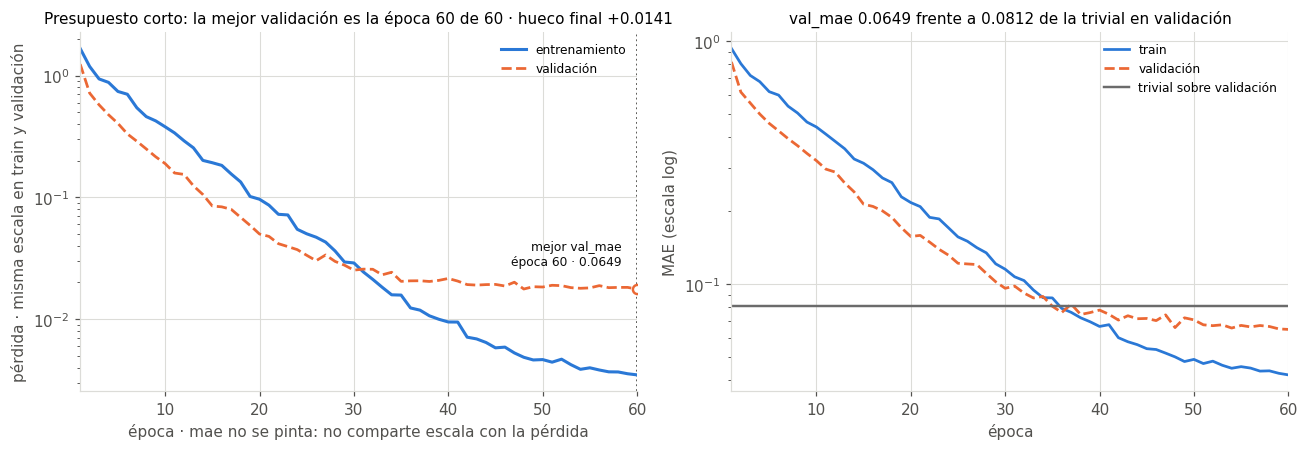

In [23]:
curva_vol = pd.read_csv(src.DIR_HISTORIALES / "baseline_volatilidad.csv")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.2))
viz.convergencia_downstream(curva_vol, eje=ejes[0])
ejes[0].set_yscale("log")   # el MSE cae dos ordenes en las primeras epocas
ejes[1].plot(curva_vol["epoca"], curva_vol["mae"], color=viz.PALETA[0], lw=1.8, label="train")
ejes[1].plot(curva_vol["epoca"], curva_vol["val_mae"], color=viz.PALETA[1], lw=1.8, ls="--",
             label="validación")
ejes[1].axhline(base_vol_val["mae"], color=viz.GRIS_CONTEXTO, lw=1.6,
                label="trivial sobre validación")
ejes[1].set_yscale("log")
ejes[1].set_xlim(float(curva_vol["epoca"].iloc[0]), float(curva_vol["epoca"].iloc[-1]))
ejes[1].set_xlabel("época")
ejes[1].set_ylabel("MAE (escala log)")
ejes[1].legend(loc="upper right", fontsize=8)
ejes[1].set_title("val_mae {:.4f} frente a {:.4f} de la trivial en validación".format(
    curva_vol["val_mae"].min(), base_vol_val["mae"]), fontsize=10, fontweight="normal")
viz.guardar(fig, "aprendizaje_baseline_volatilidad")

El modelo mejora a la trivial en el 52% de las ventanas de test.


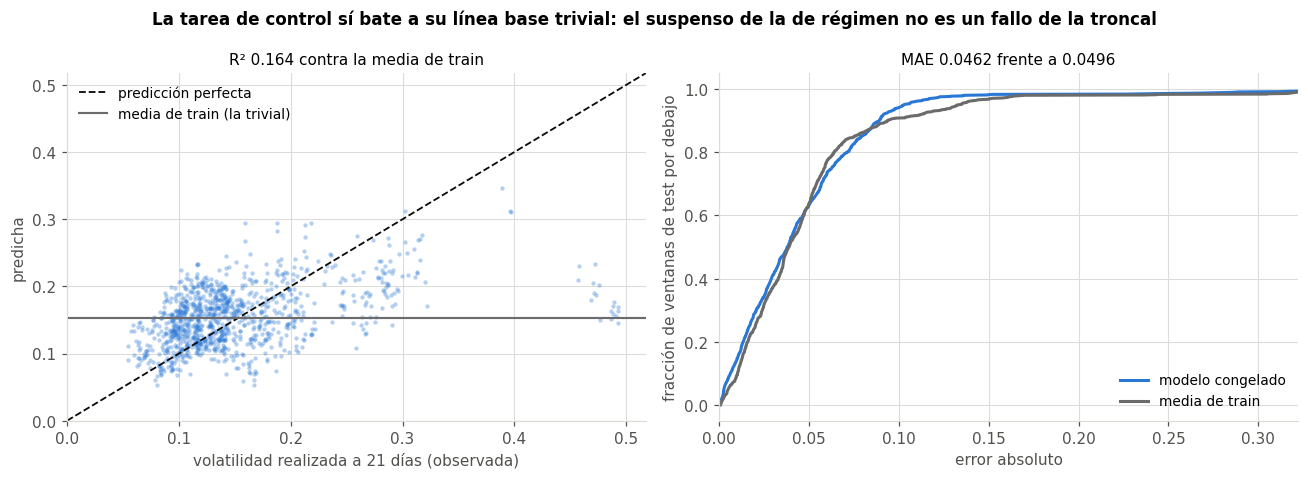

In [24]:
vol_pred = modelo_vol.predict(test.X, verbose=0, batch_size=512).ravel()
_obs = np.asarray(test.y_vol, dtype=float).ravel()
_media = float(train.y_vol.mean())

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.4))
_lim = (0.0, max(_obs.max(), vol_pred.max()) * 1.05)
ejes[0].scatter(_obs, vol_pred, s=8, alpha=0.35, color=viz.PALETA[0], linewidths=0)
ejes[0].plot(_lim, _lim, color=viz.TINTA_PRIMARIA, lw=1.2, ls="--", label="predicción perfecta")
ejes[0].axhline(_media, color=viz.GRIS_CONTEXTO, lw=1.4, label="media de train (la trivial)")
ejes[0].set_xlim(*_lim); ejes[0].set_ylim(*_lim)
ejes[0].set_xlabel("volatilidad realizada a 21 días (observada)")
ejes[0].set_ylabel("predicha")
ejes[0].legend(loc="upper left", fontsize=9)
ejes[0].set_title("R² {:.3f} contra la media de train".format(metricas_vol["r2"]),
                  fontsize=10, fontweight="normal")

for _n, _err, _t in [("modelo congelado", np.abs(vol_pred - _obs), viz.PALETA[0]),
                     ("media de train", np.abs(_media - _obs), viz.GRIS_CONTEXTO)]:
    _x = np.sort(_err)
    ejes[1].plot(_x, np.arange(1, len(_x) + 1) / len(_x), color=_t, lw=2, label=_n)
ejes[1].set_xlim(0, float(np.quantile(np.abs(_media - _obs), 0.99)))
ejes[1].set_xlabel("error absoluto")
ejes[1].set_ylabel("fracción de ventanas de test por debajo")
ejes[1].legend(loc="lower right", fontsize=9)
ejes[1].set_title("MAE {:.4f} frente a {:.4f}".format(metricas_vol["mae"], base_vol["mae"]),
                  fontsize=10, fontweight="normal")
fig.suptitle("La tarea de control sí bate a su línea base trivial: el suspenso de la de régimen "
             "no es un fallo de la troncal", fontsize=11, fontweight="bold")
viz.guardar(fig, "03_volatilidad_test")

print("El modelo mejora a la trivial en el {:.0%} de las ventanas de test.".format(
    float((np.abs(vol_pred - _obs) < np.abs(_media - _obs)).mean())))

### Lo que cuesta el barrido

El coste del cuaderno 12 se calcula con lo medido aquí, no se estima. Y las dos
magnitudes se toman **de la ganadora**, no de la media de las seis: el barrido
entrena la congelada y nada más, así que mezclar sus segundos por época con las
épocas medias del catálogo —dominadas por unas CNN que paran mucho antes—
subestimaría el coste a la mitad.

In [25]:
seg_epoca = float(resumen.loc[clave, "segundos_por_epoca_media"])
epocas_medias = float(resumen.loc[clave, "epocas_media"])
rejillas = {n: mezclas.rejilla([f"g{i}" for i in range(n)]) for n in (4, 7)}
coste = pd.DataFrame([
    {"generadores": g, "recetas": len(r), "entrenamientos": 2 * len(r),
     "horas": sum((len(train) if x.n_reales is None else x.n_reales) * (1 + x.ratio) for x in r)
              * 2 * epocas_medias * seg_epoca / len(train) / 3600}
    for g, r in rejillas.items()]).set_index("generadores")

print("Barrido a {:.2f} s/época y {:.1f} épocas efectivas de {}:".format(
    seg_epoca, epocas_medias, clave))
print(coste.round(1).to_string())

Barrido a 0.40 s/época y 51.0 épocas efectivas de lineal:
             recetas  entrenamientos  horas
generadores                                
4                165             330    2.3
7                285             570    4.0


### Lo que habría costado parar por `val_loss`

Sobre todos los entrenamientos de clasificación de este cuaderno se mide la balanced
accuracy que se habría perdido parando por la pérdida de validación en vez de por la
métrica que decide.

El estadístico es **no negativo por construcción** —es el máximo de una serie menos
un valor de esa misma serie—, así que su media no es una pérdida esperada sino un
sesgo, y la forma honesta de leerlo son los dos conteos que imprime la celda: cuántos
entrenamientos pagan más de dos puntos y cuántos no pagan absolutamente nada.

In [26]:
perdido = []
for ruta in sorted(src.DIR_HISTORIALES.glob("*.csv")):
    d = pd.read_csv(ruta)
    if "val_balanced_accuracy" not in d.columns:
        continue
    perdido.append(d["val_balanced_accuracy"].max()
                   - d["val_balanced_accuracy"].iloc[int(d["val_loss"].idxmin())])
perdido = np.array(perdido)

print("Sobre {} entrenamientos: {:.1f} puntos de media y hasta {:.1f} en el peor caso.".format(
    len(perdido), 100 * perdido.mean(), 100 * perdido.max()))
print("Reparto: {} entrenamientos pagan más de 2 puntos y {} no pagan nada (exactamente cero). "
      "La media es un sesgo, no una pérdida esperada.".format(
          int((perdido > 0.02).sum()), int((perdido == 0).sum())))

Sobre 22 entrenamientos: 1.8 puntos de media y hasta 6.6 en el peor caso.
Reparto: 10 entrenamientos pagan más de 2 puntos y 5 no pagan nada (exactamente cero). La media es un sesgo, no una pérdida esperada.


### Las curvas que faltaban

El enunciado exige curvas de pérdida **para cada entrenamiento**. Las figuras
anteriores cubren la búsqueda y la arquitectura congelada; ésta cubre los tres que no
salían en ninguna: la congelada con `class_weight` y los dos auxiliares del apartado 5.

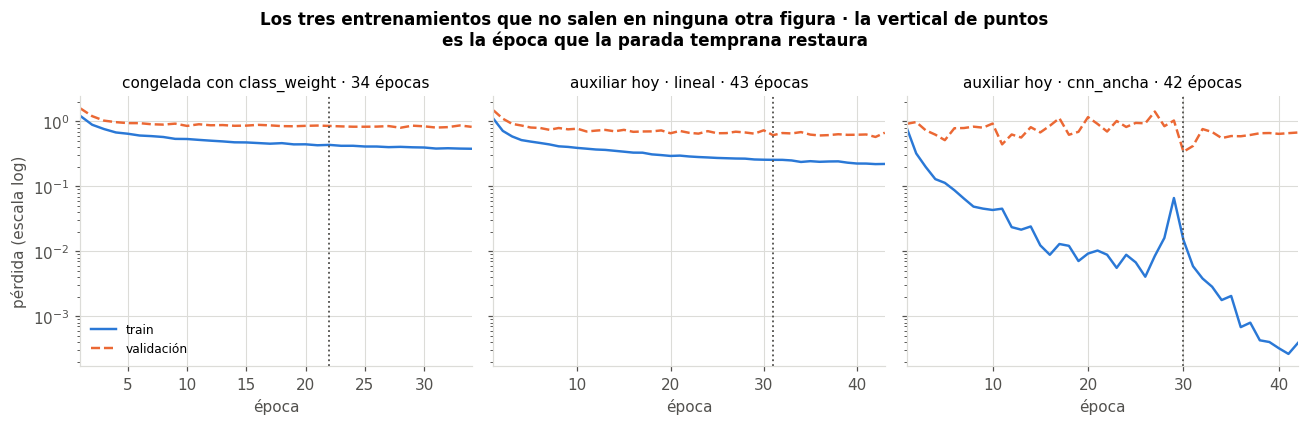

In [27]:
FALTAN = {"baseline_regimen_pesos": "congelada con class_weight",
          "auxiliar_regimen_hoy__" + clave: "auxiliar hoy" + SEP + clave,
          "auxiliar_regimen_hoy__cnn_ancha": "auxiliar hoy" + SEP + "cnn_ancha"}

fig, ejes = plt.subplots(1, len(FALTAN), figsize=(12, 3.9), sharey=True)
for _eje, (_f, _rot) in zip(ejes, FALTAN.items()):
    _c = pd.read_csv(src.DIR_HISTORIALES / f"{_f}.csv")
    _eje.plot(_c["epoca"], _c["loss"], color=viz.PALETA[0], lw=1.6, label="train")
    _eje.plot(_c["epoca"], _c["val_loss"], color=viz.PALETA[1], lw=1.6, ls="--", label="validación")
    _eje.axvline(int(_c["epoca"].iloc[_c["val_balanced_accuracy"].idxmax()]),
                 color=viz.TINTA_SECUNDARIA, ls=":", lw=1.2)
    _eje.set_xlim(1, len(_c))
    _eje.set_yscale("log")
    _eje.set_xlabel("época")
    _eje.set_title(f"{_rot} · {len(_c)} épocas", fontsize=10, fontweight="normal")
ejes[0].set_ylabel("pérdida (escala log)")
ejes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Los tres entrenamientos que no salen en ninguna otra figura · la vertical de "
             "puntos\nes la época que la parada temprana restaura", fontsize=11, fontweight="bold")
viz.guardar(fig, "03_convergencia_auxiliares")

## Qué se lleva el resto del proyecto

- **La arquitectura congelada y su presupuesto**, en `models/downstream/arquitectura.json`
  con huella. El cuaderno 12 los carga con `downstream.cargar_congelada()`, y así un
  cambio en el código entre cuadernos se detecta en vez de contaminar el barrido.
- **La barra y su banda.** La persistencia causal sobre test, y el aviso de D21
  (`docs/DECISIONES.md`): **ninguna diferencia de recall de crisis menor de unos 20
  puntos es distinguible del ruido**. La banda de bloques que imprime el apartado 1 y
  la figura del apartado 4 son de dónde sale ese umbral; ordenar la tabla del cuaderno
  12 por esa columna y quedarse con la primera fila es quedarse con el ruido más
  afortunado.
- **El control suspendido, con su causa medida.** Los bloques independientes que de
  verdad hay en train, y una formulación directa que desperdicia información que la
  ventana sí tiene.
- **El coste real del barrido**, calculado con la arquitectura que de verdad se va a
  entrenar, que decide si caben siete generadores o cuatro.

### Si el modelo no bate a "mañana como hoy", ¿qué sentido tiene medir el efecto de los sintéticos?

Es la pregunta que toca hacer, y el cuaderno ya la responde. El experimento **no**
compara el modelo contra la persistencia: compara versiones del **mismo** modelo
entrenadas con distintas mezclas de datos reales y sintéticos, y todas parten del
mismo suelo. La barra no es el rival, es la escala: dice cuánto margen hay entre donde
está el modelo y donde estaría un predictor trivial, y por tanto cuánto puede aspirar
a mover un generador. Y la banda dice qué diferencias de ese margen son legibles y
cuáles son ruido.

## Salidas generadas

In [28]:
src.DIR_METRICAS.mkdir(parents=True, exist_ok=True)
src.DIR_MODELOS_DOWN.mkdir(parents=True, exist_ok=True)

modelo.save(src.DIR_MODELOS_DOWN / "baseline_regimen.keras")
modelo_vol.save(src.DIR_MODELOS_DOWN / "baseline_volatilidad.keras")
base.round(4).to_csv(src.DIR_METRICAS / "lineas_base.csv")
resumen.round(4).to_csv(src.DIR_METRICAS / "busqueda_arquitectura.csv")
# El argumento central del apartado 5 no puede vivir solo dentro de un PNG.
informacion.round(4).to_csv(src.DIR_METRICAS / "informacion_disponible.csv")
coste.round(2).to_csv(src.DIR_METRICAS / "coste_barrido.csv")
evaluacion.acumular([
    {"variante": "regimen", "tarea": "regimen", **metricas},
    {"variante": "regimen_pesos", "tarea": "regimen", **metricas_pesos},
    {"variante": "volatilidad", "tarea": "volatilidad", **metricas_vol}], "baseline")

,variante,tarea,f1_macro,balanced_accuracy,accuracy,recall_crisis,precision_crisis,f1_crisis,soporte_crisis,conjunto,mae,rmse,sesgo,qlike,diag_predicciones_recortadas,r2
0,regimen,regimen,0.499237,0.575423,0.521863,0.590909,0.185185,0.281996,110.0,test,NaN,NaN,NaN,NaN,NaN,NaN
1,regimen_pesos,regimen,0.463913,0.555711,0.467681,0.672727,0.172897,0.275093,110.0,test,NaN,NaN,NaN,NaN,NaN,NaN
2,volatilidad,volatilidad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test,0.04619,0.064562,0.003451,0.071595,0.0,0.164051


In [29]:
from pathlib import Path

FIGURAS = ["barra_a_batir", "busqueda_arquitectura", "03_convergencia_busqueda",
           "aprendizaje_baseline_regimen", "03_veredicto", "confusion_baseline",
           "03_alarmas_crisis", "03_regimenes_test", "03_informacion_disponible",
           "aprendizaje_baseline_volatilidad", "03_volatilidad_test",
           "03_convergencia_auxiliares"]
salidas = [ruta_arq,
           src.DIR_MODELOS_DOWN / "baseline_regimen.keras",
           src.DIR_MODELOS_DOWN / "baseline_volatilidad.keras",
           src.DIR_METRICAS / "lineas_base.csv",
           src.DIR_METRICAS / "busqueda_arquitectura.csv",
           src.DIR_METRICAS / "informacion_disponible.csv",
           src.DIR_METRICAS / "coste_barrido.csv",
           src.DIR_METRICAS / "baseline.csv"] + \
          [src.DIR_FIGURAS / f"{n}.png" for n in FIGURAS]

for ruta in salidas:
    ruta = Path(ruta)
    print("[{}] {}".format("ok" if ruta.exists() else "--", ruta.relative_to(src.RAIZ)))

[ok] models\downstream\arquitectura.json
[ok] models\downstream\baseline_regimen.keras
[ok] models\downstream\baseline_volatilidad.keras
[ok] results\metricas\lineas_base.csv
[ok] results\metricas\busqueda_arquitectura.csv
[ok] results\metricas\informacion_disponible.csv
[ok] results\metricas\coste_barrido.csv
[ok] results\metricas\baseline.csv
[ok] results\figures\barra_a_batir.png
[ok] results\figures\busqueda_arquitectura.png
[ok] results\figures\03_convergencia_busqueda.png
[ok] results\figures\aprendizaje_baseline_regimen.png
[ok] results\figures\03_veredicto.png
[ok] results\figures\confusion_baseline.png
[ok] results\figures\03_alarmas_crisis.png
[ok] results\figures\03_regimenes_test.png
[ok] results\figures\03_informacion_disponible.png
[ok] results\figures\aprendizaje_baseline_volatilidad.png
[ok] results\figures\03_volatilidad_test.png
[ok] results\figures\03_convergencia_auxiliares.png


In [30]:
ENTRENAMIENTOS = len(downstream.CANDIDATAS) * len(SEMILLAS) + 5   # búsqueda + los 5 de aquí

print("Lo que este cuaderno entrega")
print("· {} entrenamientos: {} de la búsqueda ({} candidatas × {} semillas) más la congelada, "
      "la reponderada, la de volatilidad y los {} auxiliares.".format(
          ENTRENAMIENTOS, len(downstream.CANDIDATAS) * len(SEMILLAS),
          len(downstream.CANDIDATAS), len(SEMILLAS), 2))
print("· {} historiales en results/historiales/ y {} figuras declaradas, de las cuales {} "
      "existen en results/figures/.".format(
          len(list(src.DIR_HISTORIALES.glob("*.csv"))), len(FIGURAS),
          sum((src.DIR_FIGURAS / f"{n}.png").exists() for n in FIGURAS)))
print("· Veredicto del control bloqueante: {} · arquitectura {} con huella {}.".format(
    "SUPERADO" if veredicto else "SUSPENDIDO", clave, huella))
print()
print("AVISO · `segundos_por_epoca_media` ({:.2f} s) es tiempo de reloj de la máquina que "
      "ejecuta este cuaderno.".format(seg_epoca))
print("  La tabla `coste` y coste_barrido.csv cambian entre equipos; el resto de cifras, no.")

Lo que este cuaderno entrega
· 23 entrenamientos: 18 de la búsqueda (6 candidatas × 3 semillas) más la congelada, la reponderada, la de volatilidad y los 2 auxiliares.
· 23 historiales en results/historiales/ y 12 figuras declaradas, de las cuales 12 existen en results/figures/.
· Veredicto del control bloqueante: SUSPENDIDO · arquitectura lineal con huella df79bcab4ed6.

AVISO · `segundos_por_epoca_media` (0.40 s) es tiempo de reloj de la máquina que ejecuta este cuaderno.
  La tabla `coste` y coste_barrido.csv cambian entre equipos; el resto de cifras, no.
